In [2]:
%pip install -q astropy scipy pandas matplotlib photutils scikit-image

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Import all required packages
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS

from scipy import ndimage
from scipy.spatial import cKDTree

In [10]:
# Find the project root directory
PROJECT_ROOT = Path.cwd()

# Move one level up if the notebook is running inside the notebooks directory
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Define project directories
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CATALOG_DIR = PROJECT_ROOT / "data" / "catalog"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_CATALOG_DIR = OUTPUT_DIR / "catalogs"

# Create output directories if necessary
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CATALOG_DIR.mkdir(parents=True, exist_ok=True)

# Define input file paths
fits_path = RAW_DIR / "SKAMid_B2_1000h_v3.fits"
catalog_path = CATALOG_DIR / "TrainingSet_B2_v2.txt"

print("Project root:", PROJECT_ROOT)
print("FITS exists:", fits_path.exists())
print("Catalogue exists:", catalog_path.exists())

Project root: D:\AST\radio_ska
FITS exists: True
Catalogue exists: True


In [11]:
# Define the actual catalogue columns
catalog_columns = [
    "ID",
    "RA_core",
    "DEC_core",
    "RA_centroid",
    "DEC_centroid",
    "FLUX",
    "Core_frac",
    "BMAJ",
    "BMIN",
    "PA",
    "SIZE",
    "CLASS",
    "SELECTION",
    "x",
    "y",
]

# Read the official training catalogue
catalog = pd.read_csv(
    catalog_path,
    sep=r"\s+",
    skiprows=18,
    names=catalog_columns
)

print("Number of catalogue sources:", len(catalog))

catalog.head()

Number of catalogue sources: 70737


,ID,RA_core,DEC_core,RA_centroid,DEC_centroid,FLUX,Core_frac,BMAJ,BMIN,PA,SIZE,CLASS,SELECTION,x,y
0,19583869,-0.027182,-29.880180,-0.025822,-29.881343,1.516060e-05,0.009637,242.875,124.447,19.617,1,1,1,16716.479,18150.308
1,2279500,-0.025735,-29.843031,-0.019444,-29.840956,4.334940e-08,0.000000,406.903,218.836,202.725,1,1,1,16634.210,18751.864
2,6762901,-0.102810,-29.801121,-0.102775,-29.800858,1.202550e-08,0.003818,25.171,14.669,340.299,1,1,1,17711.346,19348.530
3,34081021,-0.096500,-29.755894,-0.096451,-29.755994,1.173220e-07,0.014234,15.444,8.729,245.804,1,1,1,17630.171,20016.821
4,13118570,-0.123563,-29.939310,-0.123545,-29.939322,7.068320e-08,0.016659,20.497,14.044,32.453,1,1,1,17977.586,17285.915


In [12]:
# Keep only sources that were injected into the simulated image
truth = catalog[catalog["SELECTION"] == 1].copy()

truth = truth.reset_index(drop=True)

print("All catalogue entries:", len(catalog))
print("Injected truth sources:", len(truth))

All catalogue entries: 70737
Injected truth sources: 46307


In [13]:
# Determine the pixel boundaries of the training region
padding = 20

x_min = max(0, int(np.floor(catalog["x"].min())) - padding)
x_max = int(np.ceil(catalog["x"].max())) + padding

y_min = max(0, int(np.floor(catalog["y"].min())) - padding)
y_max = int(np.ceil(catalog["y"].max())) + padding

print("Training region:")
print("x:", x_min, "to", x_max)
print("y:", y_min, "to", y_max)

print("Width:", x_max - x_min)
print("Height:", y_max - y_min)

Training region:
x: 16363 to 19879
y: 17252 to 20477
Width: 3516
Height: 3225


In [14]:
# Read only the training region from the large FITS image
with fits.open(fits_path, memmap=True) as hdul:
    full_image = np.squeeze(hdul[0].data)
    header = hdul[0].header.copy()

    training_image = full_image[
        y_min:y_max,
        x_min:x_max
    ].astype(np.float32, copy=True)

print("Training image shape:", training_image.shape)
print("Data type:", training_image.dtype)

Training image shape: (3225, 3516)
Data type: float32


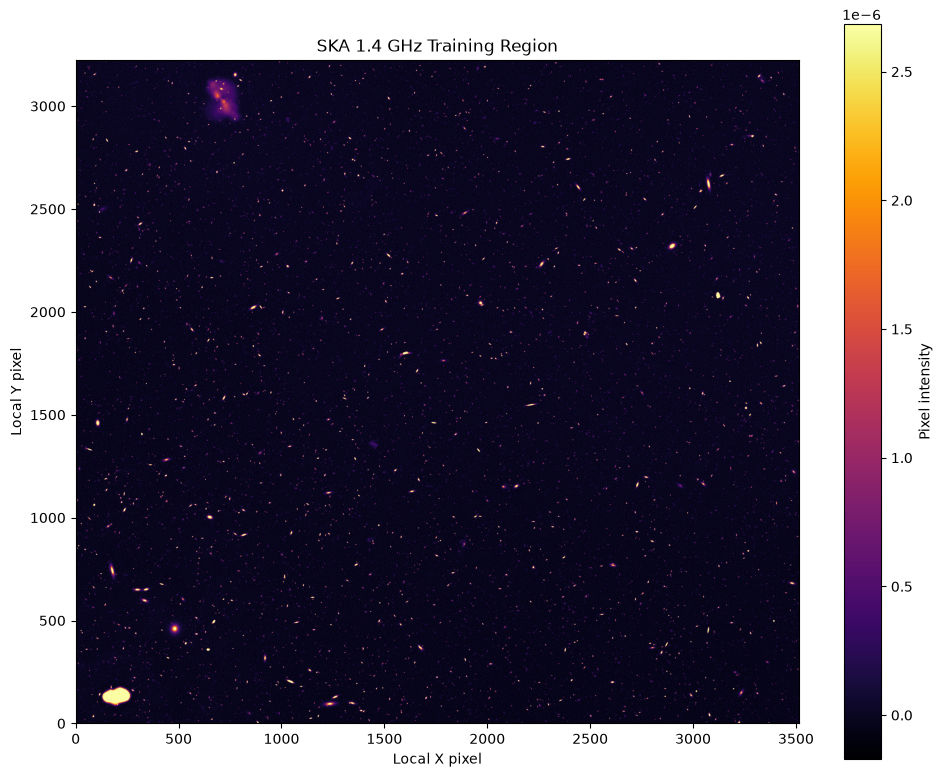

In [16]:
# Calculate robust display limits
finite_pixels = training_image[np.isfinite(training_image)]

vmin = np.percentile(finite_pixels, 1)
vmax = np.percentile(finite_pixels, 99.8)

# Visualize the training region
plt.figure(figsize=(10, 8))

plt.imshow(
    training_image,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Pixel intensity")
plt.xlabel("Local X pixel")
plt.ylabel("Local Y pixel")
plt.title("SKA 1.4 GHz Training Region")

plt.tight_layout()
plt.show()

In [17]:
# Estimate the background level
background = np.median(finite_pixels)

# Estimate the noise using the median absolute deviation
mad = np.median(
    np.abs(finite_pixels - background)
)

sigma = 1.4826 * mad

# Define the detection level
n_sigma = 5

threshold = background + n_sigma * sigma

print("Background:", background)
print("Sigma:", sigma)
print("5-sigma threshold:", threshold)

Background: -1.4525004e-08
Sigma: 6.9855005e-08
5-sigma threshold: 3.3475e-07


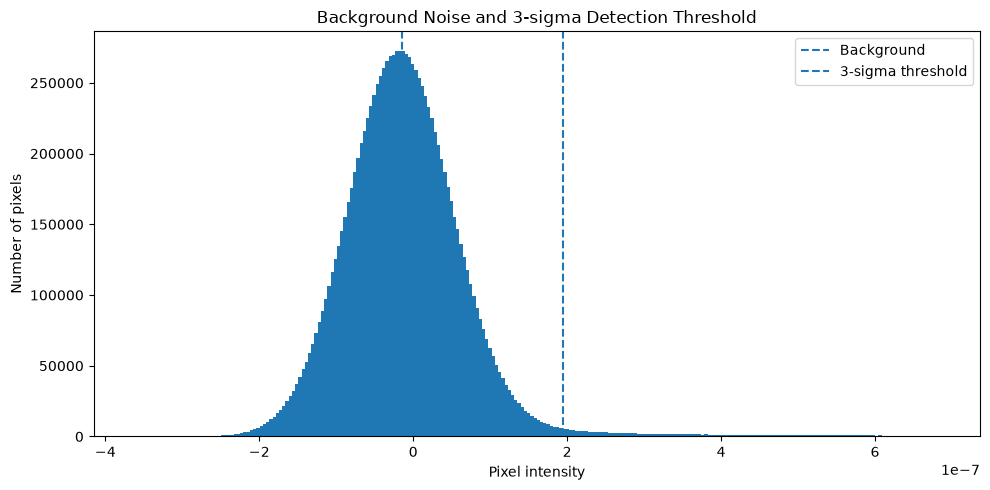

Background: -1.4525004e-08
Sigma: 6.9855005e-08
3-sigma threshold: 1.9504002e-07


In [22]:
# Define the 3-sigma detection threshold
n_sigma = 3

threshold = background + n_sigma * sigma

# Select a useful intensity range for the histogram
hist_low = background - 5 * sigma
hist_high = background + 10 * sigma

hist_pixels = finite_pixels[
    (finite_pixels >= hist_low) &
    (finite_pixels <= hist_high)
]

# Plot the pixel intensity distribution
plt.figure(figsize=(10, 5))

plt.hist(
    hist_pixels,
    bins=250
)

plt.axvline(
    background,
    linestyle="--",
    label="Background"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="3-sigma threshold"
)

plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.title("Background Noise and 3-sigma Detection Threshold")

plt.legend()
plt.tight_layout()
plt.show()

print("Background:", background)
print("Sigma:", sigma)
print("3-sigma threshold:", threshold)

In [23]:
# Create a binary detection mask
detection_mask = training_image > threshold

print("Total pixels:", detection_mask.size)
print("Pixels above 3 sigma:", detection_mask.sum())

Total pixels: 11339100
Pixels above 3 sigma: 273944


In [24]:
# Define eight-pixel connectivity
structure = np.ones((3, 3), dtype=int)

# Label connected groups of above-threshold pixels
labeled_image, number_of_components = ndimage.label(
    detection_mask,
    structure=structure
)

print("Initial connected components:", number_of_components)

Initial connected components: 18751


In [25]:
# Find bounding slices for all connected components
component_slices = ndimage.find_objects(labeled_image)

# Require at least this many connected pixels
min_pixels = 3

detected_sources = []

for label_id, source_slice in enumerate(component_slices, start=1):

    if source_slice is None:
        continue

    component = (
        labeled_image[source_slice] == label_id
    )

    area = int(component.sum())

    if area < min_pixels:
        continue

    source_image = training_image[source_slice]

    weights = np.where(
        component,
        source_image - background,
        0.0
    )

    total_weight = weights.sum()

    if total_weight <= 0:
        continue

    yy, xx = np.indices(source_image.shape)

    local_component_x = (
        weights * xx
    ).sum() / total_weight

    local_component_y = (
        weights * yy
    ).sum() / total_weight

    local_x = (
        source_slice[1].start +
        local_component_x
    )

    local_y = (
        source_slice[0].start +
        local_component_y
    )

    global_x = local_x + x_min
    global_y = local_y + y_min

    peak_intensity = source_image[component].max()

    detected_sources.append(
        {
            "x": global_x,
            "y": global_y,
            "area_pixels": area,
            "peak_intensity": peak_intensity,
            "peak_snr": (
                peak_intensity - background
            ) / sigma,
        }
    )

detections = pd.DataFrame(detected_sources)

detections.insert(
    0,
    "detection_id",
    np.arange(1, len(detections) + 1)
)

print("Detected candidate sources:", len(detections))

detections.head()

Detected candidate sources: 10975


,detection_id,x,y,area_pixels,peak_intensity,peak_snr
0,1,16386.957800,17252.118108,4,6.519887e-07,9.541388
1,2,16462.184016,17252.432301,13,5.063104e-07,7.455950
2,3,16602.991241,17253.206953,5,3.402199e-07,5.078303
3,4,16713.758556,17255.228528,83,9.789346e-07,14.221738
4,5,16806.926834,17252.225730,4,4.309703e-07,6.377428


In [26]:
# Create the celestial coordinate transformation
wcs = WCS(header).celestial

# Convert detected pixel positions to sky coordinates
ra_deg, dec_deg = wcs.pixel_to_world_values(
    detections["x"].to_numpy(),
    detections["y"].to_numpy()
)

detections["RA_deg"] = ra_deg
detections["DEC_deg"] = dec_deg

detections.head()

,detection_id,x,y,area_pixels,peak_intensity,peak_snr,RA_deg,DEC_deg
0,1,16386.957800,17252.118108,4,6.519887e-07,9.541388,359.999693,-29.941649
1,2,16462.184016,17252.432301,13,5.063104e-07,7.455950,359.993865,-29.941627
2,3,16602.991241,17253.206953,5,3.402199e-07,5.078303,359.982955,-29.941574
3,4,16713.758556,17255.228528,83,9.789346e-07,14.221738,359.974373,-29.941437
4,5,16806.926834,17252.225730,4,4.309703e-07,6.377428,359.967154,-29.941637


In [27]:
# Build a spatial search tree from truth-source positions
truth_positions = truth[
    ["x", "y"]
].to_numpy()

detection_positions = detections[
    ["x", "y"]
].to_numpy()

truth_tree = cKDTree(truth_positions)

# Define the maximum matching distance in pixels
match_radius = 5.0

distances, truth_indices = truth_tree.query(
    detection_positions,
    distance_upper_bound=match_radius
)

# Keep only valid candidate matches
valid = truth_indices < len(truth)

match_candidates = pd.DataFrame(
    {
        "detection_index": np.where(valid)[0],
        "truth_index": truth_indices[valid],
        "distance_pixels": distances[valid],
    }
)

# Keep only the closest detection for each truth source
matches = (
    match_candidates
    .sort_values("distance_pixels")
    .drop_duplicates(
        subset="truth_index",
        keep="first"
    )
    .reset_index(drop=True)
)

print("Matched sources:", len(matches))

Matched sources: 10415


In [28]:
# Count correct, false, and missed detections
true_positive = len(matches)

false_positive = (
    len(detections) - true_positive
)

false_negative = (
    len(truth) - true_positive
)

# Calculate evaluation metrics
precision = (
    true_positive /
    (true_positive + false_positive)
    if true_positive + false_positive > 0
    else 0.0
)

recall = (
    true_positive /
    (true_positive + false_negative)
    if true_positive + false_negative > 0
    else 0.0
)

f1 = (
    2 * precision * recall /
    (precision + recall)
    if precision + recall > 0
    else 0.0
)

print("Detection threshold: 3 sigma")
print("True positives:", true_positive)
print("False positives:", false_positive)
print("False negatives:", false_negative)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 score:  {f1:.3f}")

Detection threshold: 3 sigma
True positives: 10415
False positives: 560
False negatives: 35892
Precision: 0.949
Recall:    0.225
F1 score:  0.364


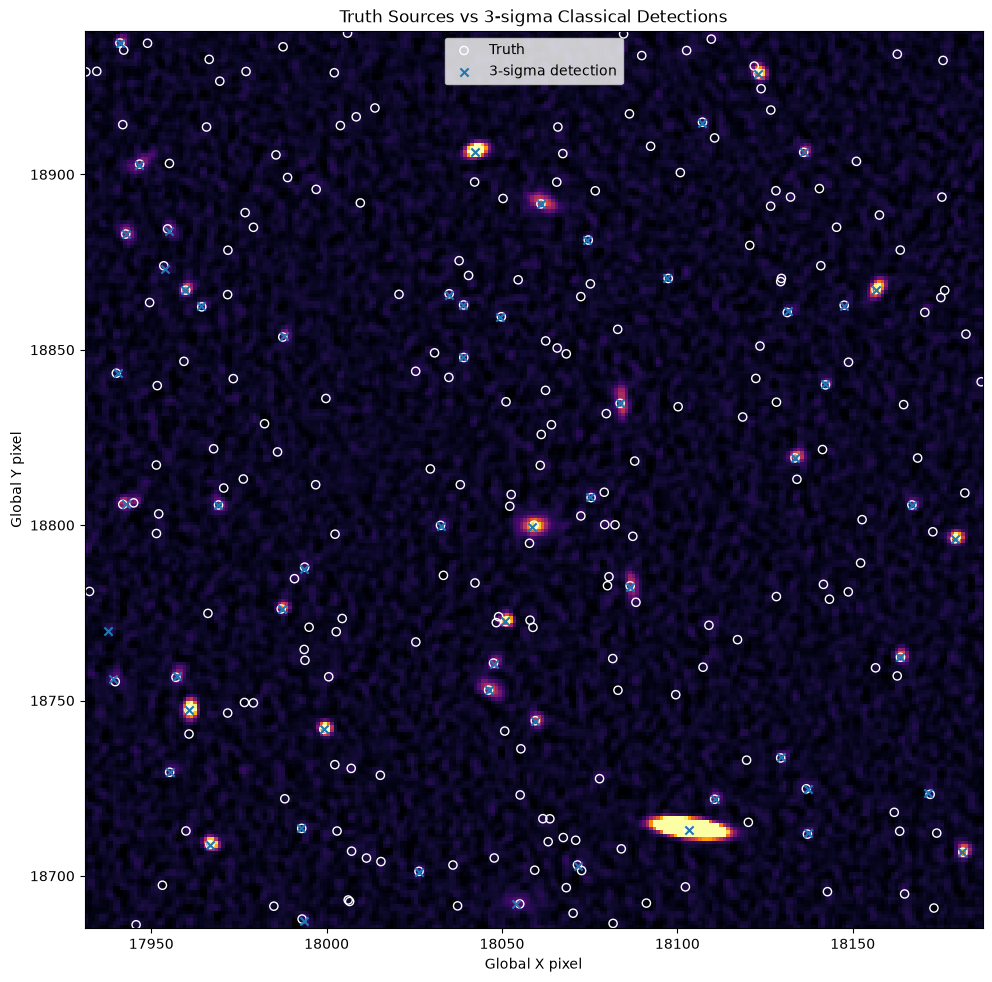

In [29]:
# Define a local region for visual comparison
view_size = 256

center_x = int(np.median(truth["x"]))
center_y = int(np.median(truth["y"]))

view_x_min = center_x - view_size // 2
view_x_max = center_x + view_size // 2

view_y_min = center_y - view_size // 2
view_y_max = center_y + view_size // 2

# Convert global coordinates into training-image coordinates
local_x_min = view_x_min - x_min
local_x_max = view_x_max - x_min

local_y_min = view_y_min - y_min
local_y_max = view_y_max - y_min

view_image = training_image[
    local_y_min:local_y_max,
    local_x_min:local_x_max
]

# Select truth sources inside the displayed region
truth_view = truth[
    (truth["x"] >= view_x_min) &
    (truth["x"] < view_x_max) &
    (truth["y"] >= view_y_min) &
    (truth["y"] < view_y_max)
]

# Select detections inside the displayed region
detections_view = detections[
    (detections["x"] >= view_x_min) &
    (detections["x"] < view_x_max) &
    (detections["y"] >= view_y_min) &
    (detections["y"] < view_y_max)
]

# Calculate display limits
view_pixels = view_image[np.isfinite(view_image)]

view_vmin = np.percentile(view_pixels, 1)
view_vmax = np.percentile(view_pixels, 99.8)

# Display image and source positions
plt.figure(figsize=(10, 10))

plt.imshow(
    view_image,
    origin="lower",
    cmap="inferno",
    vmin=view_vmin,
    vmax=view_vmax,
    extent=[
        view_x_min,
        view_x_max,
        view_y_min,
        view_y_max,
    ]
)

plt.scatter(
    truth_view["x"],
    truth_view["y"],
    facecolors="none",
    edgecolors="white",
    s=35,
    label="Truth"
)

plt.scatter(
    detections_view["x"],
    detections_view["y"],
    marker="x",
    s=35,
    label="3-sigma detection"
)

plt.xlabel("Global X pixel")
plt.ylabel("Global Y pixel")
plt.title("Truth Sources vs 3-sigma Classical Detections")

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Add a matching flag to every truth source
truth_analysis = truth.copy()

truth_analysis["matched"] = False

matched_truth_indices = matches[
    "truth_index"
].to_numpy()

truth_analysis.loc[
    matched_truth_indices,
    "matched"
] = True

print(
    truth_analysis["matched"].value_counts()
)

matched
False    35892
True     10415
Name: count, dtype: int64


In [32]:
# Create logarithmic flux bins
flux_min = truth_analysis["FLUX"].min()
flux_max = truth_analysis["FLUX"].max()

flux_bins = np.logspace(
    np.log10(flux_min),
    np.log10(flux_max),
    12
)

truth_analysis["flux_bin"] = pd.cut(
    truth_analysis["FLUX"],
    bins=flux_bins
)

# Calculate completeness in every flux interval
completeness_table = (
    truth_analysis
    .groupby(
        "flux_bin",
        observed=False
    )
    .agg(
        total_sources=("matched", "size"),
        detected_sources=("matched", "sum")
    )
)

completeness_table["completeness"] = (
    completeness_table["detected_sources"] /
    completeness_table["total_sources"]
)

# Calculate the geometric center of each flux interval
completeness_table["flux_center"] = [
    np.sqrt(interval.left * interval.right)
    for interval in completeness_table.index
]

completeness_table

,total_sources,detected_sources,completeness,flux_center
flux_bin,,,,
"(1e-08, 3.69e-08]",7690,33,0.004291,1.920937e-08
"(3.69e-08, 1.36e-07]",18322,114,0.006222,7.084067e-08
"(1.36e-07, 5.03e-07]",10650,1600,0.150235,2.615492e-07
"(5.03e-07, 1.85e-06]",5761,5034,0.873807,9.646502e-07
"(1.85e-06, 6.84e-06]",2669,2475,0.927314,3.557246e-06
"(6.84e-06, 2.53e-05]",943,904,0.958643,1.315492e-05
"(2.53e-05, 9.32e-05]",213,200,0.938967,4.855883e-05
"(9.32e-05, 0.000344]",46,43,0.934783,1.790553e-04
"(0.000344, 0.00127]",8,8,1.000000,6.609690e-04


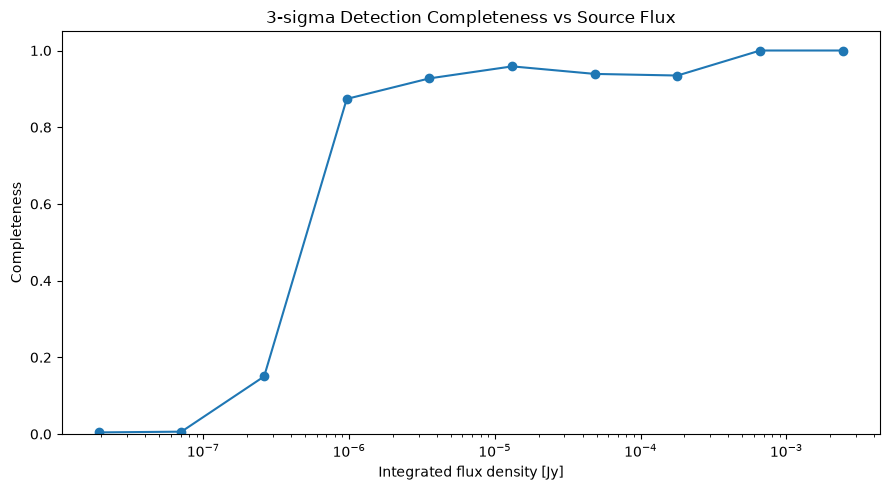

In [33]:
# Plot detection completeness as a function of source flux
plt.figure(figsize=(9, 5))

plt.semilogx(
    completeness_table["flux_center"],
    completeness_table["completeness"],
    marker="o"
)

plt.xlabel("Integrated flux density [Jy]")
plt.ylabel("Completeness")
plt.title("3-sigma Detection Completeness vs Source Flux")

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [34]:
# Save the detected-source catalogue
detections.to_csv(
    OUTPUT_CATALOG_DIR /
    "classical_3sigma_detected_sources.csv",
    index=False
)

# Save source matching results
matches.to_csv(
    OUTPUT_CATALOG_DIR /
    "classical_3sigma_truth_matches.csv",
    index=False
)

# Save the completeness analysis
completeness_table.to_csv(
    OUTPUT_CATALOG_DIR /
    "classical_3sigma_completeness_vs_flux.csv"
)

print("3-sigma results saved.")

3-sigma results saved.
